In [ ]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.trainers.ppo.ppo_trainer import PPOTrainer
# from reflect.components.models.actor import Actor
# from reflect.components.trainers.value.value_trainer import ValueGradTrainer
# from reflect.components.trainers.value.critic import ValueCritic

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
import torch.nn as nn
from torch.distributions import Normal


/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
env = gym.make('Pendulum-v1', render_mode='rgb_array')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
device='cpu'


In [3]:

from torch.distributions import Normal
from torch import nn

def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    torch.nn.init.orthogonal_(layer.weight, std)
    torch.nn.init.constant_(layer.bias, bias_const)
    return layer


class Actor(torch.nn.Module):
    def __init__(
            self,
            input_dim,
            output_dim,
        ):
        super().__init__()
        self.actor_mean = nn.Sequential(
            layer_init(nn.Linear(np.array(input_dim).prod(), 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, np.prod(output_dim)), std=0.01),
        )
        self.actor_logstd = nn.Parameter(torch.zeros(1, np.prod(output_dim)))

    def forward(self, x, deterministic=False):
        action_mean = self.actor_mean(x)
        # action_mean = torch.tanh(action_mean)
        if deterministic:
            return action_mean
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        probs = Normal(action_mean, action_std)
        return probs


class Critic(nn.Module):
    def __init__(
            self,
            input_dim
        ):
        super().__init__()
        self.critic = nn.Sequential(
            layer_init(nn.Linear(np.array(input_dim).prod(), 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, 256)),
            nn.ReLU(),
            layer_init(nn.Linear(256, 1), std=1.0),
        )

    def forward(self, x):
        return self.critic(x)

In [4]:

actor = Actor(
    input_dim=env.observation_space.shape[0],
    output_dim=env.action_space.shape[0],
).to(device)

critic = Critic(
    input_dim=env.observation_space.shape[0],
).to(device)

trainer = PPOTrainer(
    actor=actor,
    critic=critic,
    lr=1e-4,
    gamma=0.99,
    lam=0.95,
    grad_clip=0.5,
    num_minibatch=1,
    update_epochs=10,
    clip_ratio=0.01,
    target_kl=0.01,
    eta=0.0,
    vf_coef=0.08
)
trainer.to(device)

In [5]:

world_model_actor = WorldModelActor(
    actor=actor,
)

env_data_loader = EnvDataLoader(
    num_time_steps=3,
    rollout_length=200,
    num_runs=1000,
    noise_size=0.3,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [6]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

100%|██████████| 10/10 [00:02<00:00,  3.65it/s]


In [7]:
state_dim = 3+1+1
action_dim = 1

# dynamic_model = DynamicFlowModel(
#     input_dim=state_dim,
#     conditioning_dim=3*(state_dim + action_dim),
#     output_dim=state_dim,
#     time_embed_dim=16,
#     hidden_dim=128,
#     depth=2,
#     use_layer_norm=True,
#     num_positions=3,
# )

# world_model = WorldModel(
#     dynamic_model=dynamic_model,
#     observation_dim=state_dim-2,
#     action_dim=action_dim,
#     environment_action_bound=env.action_space.high,
# )

dynamic_model = DynamicAttentionalFlowModel(
    input_dim=state_dim,
    conditioning_dim=state_dim + action_dim,
    output_dim=state_dim,
    num_heads=4,
    hidden_dim=256,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

world_model = WorldModel(
    dynamic_model=dynamic_model,
    observation_dim=state_dim-2,
    action_dim=action_dim,
    environment_action_bound=env.action_space.high,
)


In [8]:
def test_actor(actor, env, render=False):
    o, *_ = env.reset()
    total_reward = 0
    images = []
    for _ in range(1000):
        a = actor(torch.tensor(o), deterministic=True)
        o, r, d, *_ = env.step(a.detach())
        if render:
            images.append(env.render())
        total_reward += r
        if d:
            break
    if render:
        return total_reward, images
    else:
        return total_reward

test_actor(actor, env)


tensor(-5455.4775)

In [9]:
def load_init_states(env_data_loader, batch_size, num_time_steps):
    max_index = min(env_data_loader.rollout_ind, env_data_loader.num_runs)
    indices = torch.randint(0, max_index, (batch_size,))
    return (
        env_data_loader.state_buffer[indices, :num_time_steps].detach(),
        env_data_loader.action_buffer[indices, :num_time_steps].detach(),
        env_data_loader.reward_buffer[indices, :num_time_steps].unsqueeze(-1).detach(),
        env_data_loader.done_buffer[indices, :num_time_steps].unsqueeze(-1).detach(),
    )

In [10]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
    'value_loss': ['value_loss'],
    'actor_loss': ['actor_loss'],
    'reward': ['reward'],
    'imagined_reward': ['imagined_reward'],
    'grad_norm': ['grad_norm'],
    'clipfrac': ['clipfrac'],
    'approxkl': ['approxkl'],
    'entropy_loss': ['entropy_loss']
  },
)

In [11]:
for epoch in tqdm(range(50)):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=4
    )
    world_model_losses = world_model.update(o, a, r, d)

100%|██████████| 50/50 [00:32<00:00,  1.55it/s]


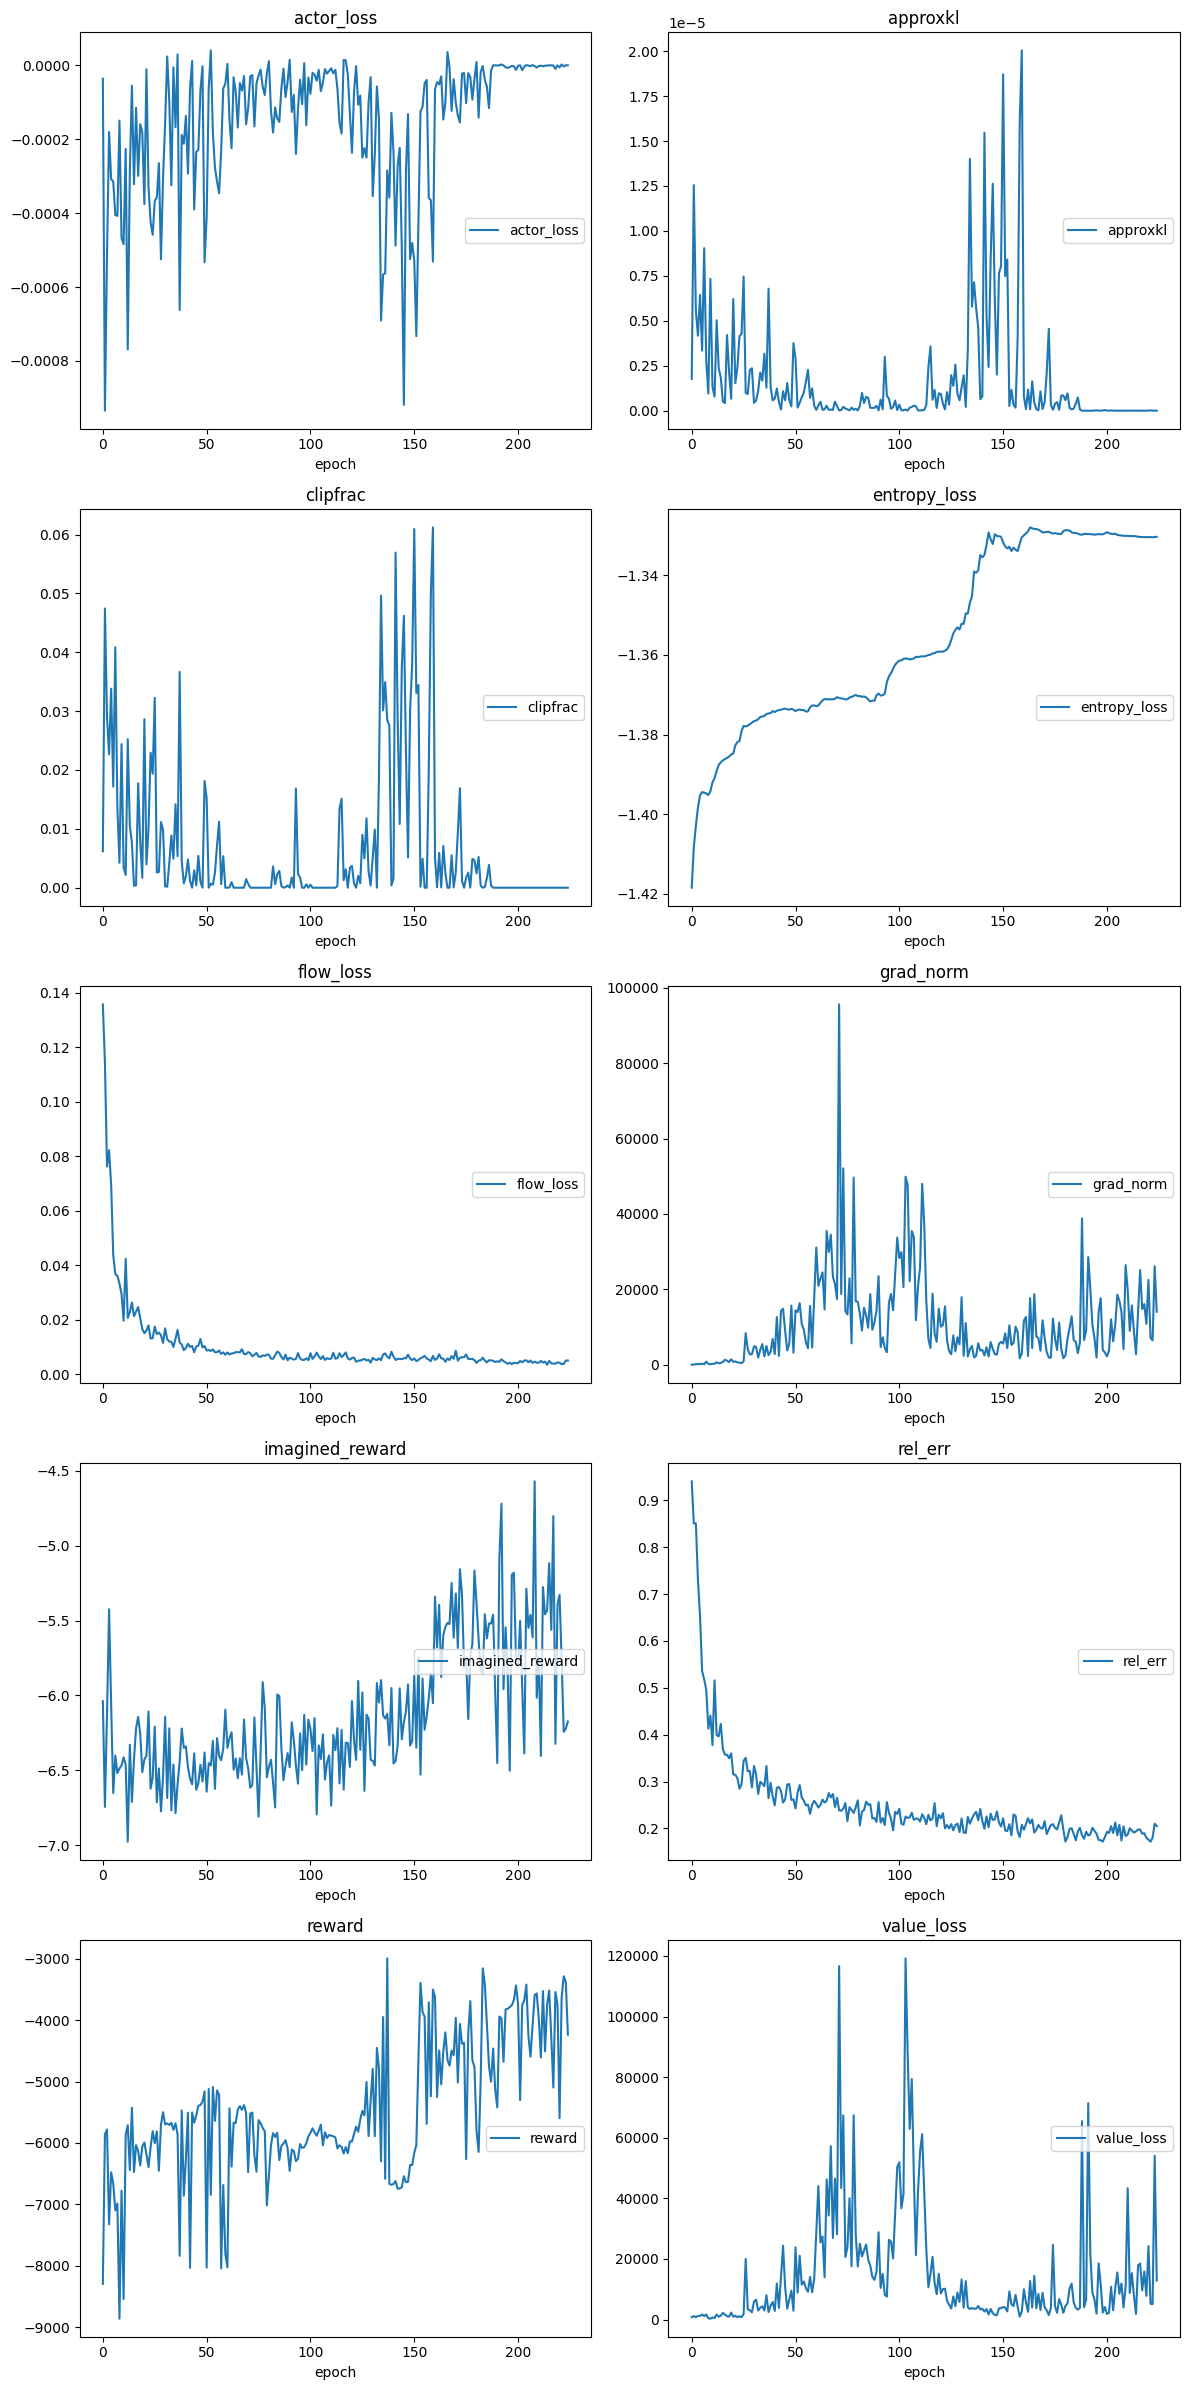

actor_loss
	actor_loss       	 (min:   -0.001, max:    0.000, cur:   -0.000)
approxkl
	approxkl         	 (min:    0.000, max:    0.000, cur:    0.000)
clipfrac
	clipfrac         	 (min:    0.000, max:    0.061, cur:    0.000)
entropy_loss
	entropy_loss     	 (min:   -1.418, max:   -1.328, cur:   -1.330)
flow_loss
	flow_loss        	 (min:    0.003, max:    0.136, cur:    0.005)
grad_norm
	grad_norm        	 (min:   16.807, max: 95572.661, cur: 14059.190)
imagined_reward
	imagined_reward  	 (min:   -6.976, max:   -4.571, cur:   -6.174)
rel_err
	rel_err          	 (min:    0.172, max:    0.940, cur:    0.205)
reward
	reward           	 (min: -8864.357, max: -2991.884, cur: -4235.227)
value_loss
	value_loss       	 (min:  263.735, max: 119219.868, cur: 12846.355)


KeyboardInterrupt: 

: 

In [ ]:

update_every = 10

for epoch in range(2_000):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=512,
        num_time_steps=4
    )
    world_model_losses = world_model.update(o, a, r, d)

    # ppo training step

    # o, a, r, d = load_init_states(env_data_loader, 256, 3)
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=16,
        num_time_steps=3
    )

    o.requires_grad = True
    a.requires_grad = True
    r.requires_grad = True
    d = d.to(torch.float32)
    d.requires_grad = True

    img_o, img_a, img_r, img_d = world_model.imagine_rollout(
        o, a, r, d,
        actor,
        num_timesteps=100,
        num_flow_steps=3,
        noise_scale=0.0,
        disable_gradients=True
    )

    trainer_history = trainer.update(
        state_samples=img_o,
        reward_samples=img_r,
        done_samples=img_d,
        action_samples=img_a,
        num_minibatch=4,
        update_epochs=10,
    )

    trainer_history = asdict(trainer_history)
    world_model_losses = asdict(world_model_losses)
    if epoch % update_every == 0:
        plot_losses.update(
            {
                **world_model_losses,
                **trainer_history,
                'reward': test_actor(actor, env),
                'imagined_reward': img_r.detach().sum(-1).mean()
            }
        )
        plot_losses.send()
        total_loss = 0 
        total_rel_err = 0


100%|██████████| 200/200 [00:01<00:00, 128.45it/s]


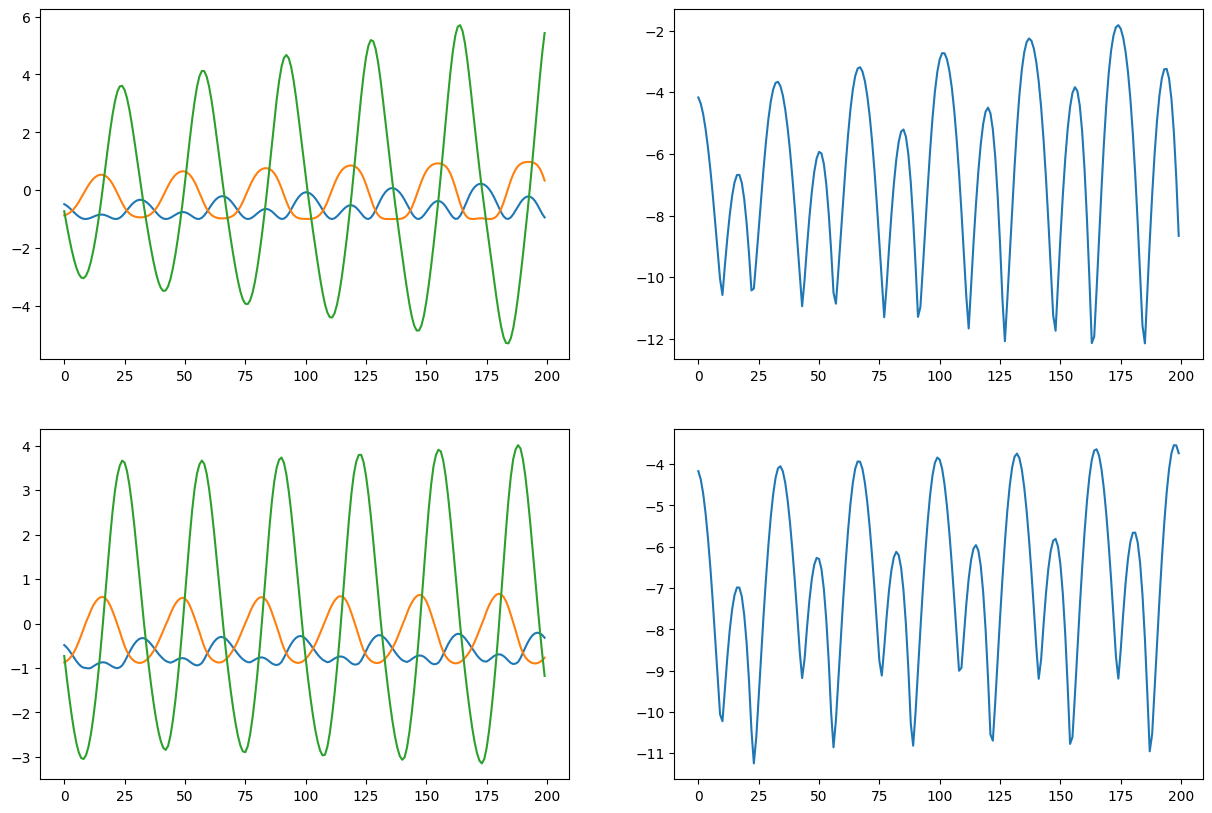

In [17]:
o, *_ = env.reset()
total_reward = 0
images = []
obs = []
actions = []
rewards = []
dones = []

for _ in tqdm(range(200)):
    a = actor(torch.tensor(o).to(torch.float32).to(device), deterministic=True)
    a = a.cpu().detach().numpy()
    o, r, d, t, info = env.step(a)
    obs.append(o)
    actions.append(a)
    rewards.append(r)
    dones.append(d)
    images.append(env.render())
    if d:
        break

o = torch.tensor(obs)[None]
a = torch.tensor(actions)[None]
r = torch.tensor(rewards)[None, :, None].to(torch.float32)
d = torch.tensor(dones)[None, :, None].to(torch.float32)

import matplotlib.pyplot as plt
import random

start_i=0
length=200

img_o, img_a, img_r, img_d = world_model.imagine_rollout(
    o[:, start_i:start_i+10],
    a[:, start_i:start_i+10],
    r[:, start_i:start_i+10],
    d[:, start_i:start_i+10],
    actor,
    num_timesteps=length,
    num_flow_steps=5,
    noise_scale=0.001
)

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(15, 10))
axs[0, 0].plot(o[0, start_i:length+start_i, 0].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 1].cpu())
axs[0, 0].plot(o[0, start_i:length+start_i, 2].cpu())
axs[0, 1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[1, 0].plot(img_o[0, :length, 0].cpu())
axs[1, 0].plot(img_o[0, :length, 1].cpu())
axs[1, 0].plot(img_o[0, :length, 2].cpu())
axs[1, 1].plot(img_r[0, :length, 0].cpu())

plt.show()

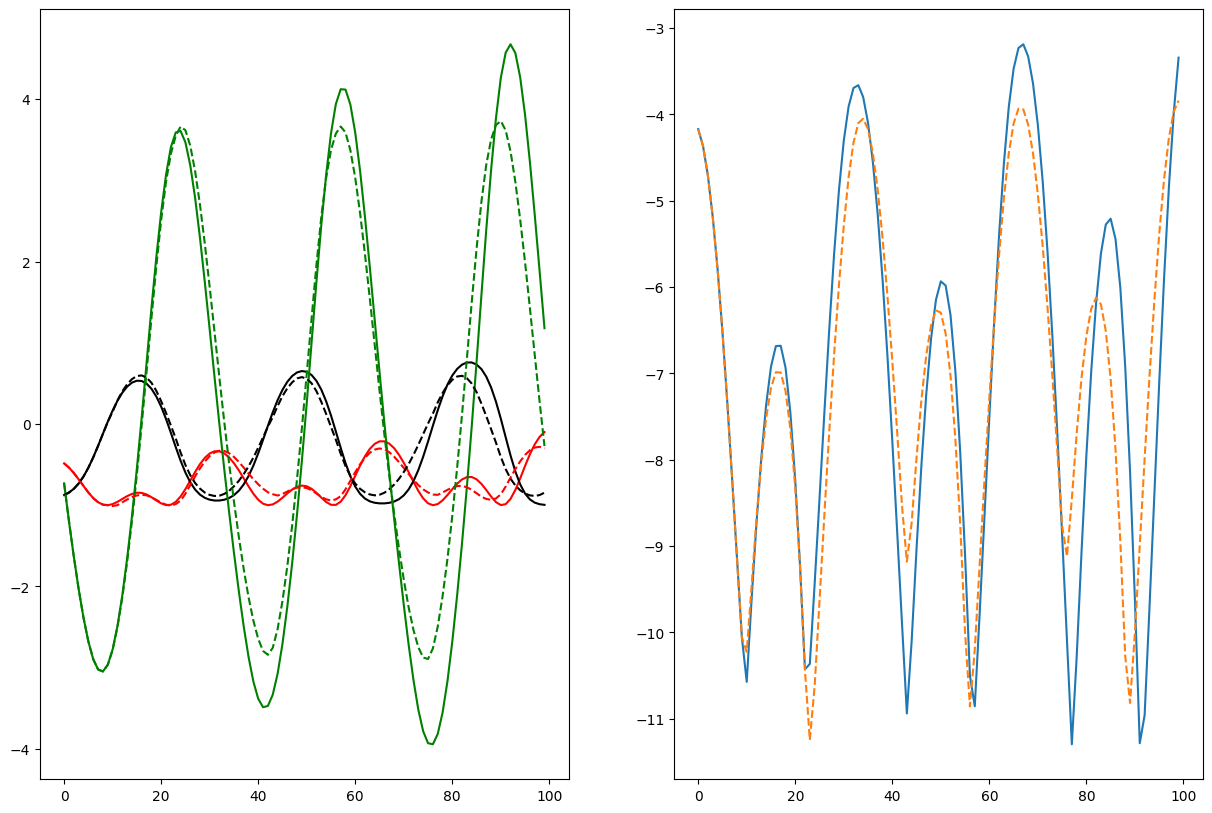

In [18]:
start_i=0
length=100

img_o = img_o.detach()
img_r = img_r.detach()
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(15, 10))
axs[0].plot(o[0, start_i:length+start_i, 0].cpu(), color='red', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 1].cpu(), color='black', linestyle='-')
axs[0].plot(o[0, start_i:length+start_i, 2].cpu(), color='green', linestyle='-')
axs[1].plot(r[0, start_i:length+start_i, 0].cpu())

axs[0].plot(img_o[0, :length, 0].cpu(), color='red', linestyle='--',)
axs[0].plot(img_o[0, :length, 1].cpu(), color='black', linestyle='--',)
axs[0].plot(img_o[0, :length, 2].cpu(), color='green', linestyle='--',)
axs[1].plot(img_r[0, :length, 0].cpu(), linestyle='--',)

plt.show()

In [19]:
reward, images = test_actor(actor, env, render=True)
print(reward)

tensor(-4646.9517)


In [20]:
from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Display first frame
im = ax.imshow(images[0])

# Animation update function
def update(frame):
    im.set_array(images[frame])
    return [im]

# Create animation
anim = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(images),
    interval=20,  # milliseconds between frames (50 FPS)
    blit=True
)

# Display in notebook
plt.close()  # Prevent static image from showing
HTML(anim.to_html5_video())